# Project Overview

This project examines how three machine learning algorithms, KNN, Logistic Regression, and Random Forest,
perform when predicting whether a student will dropout from university. Additionally, the project compares
the results of each model before and after hyperparameter tuning and uses learning curves to
examine how the sample size affects each model's performance.

The dataset used in this project was created for the study "Predicting Student Dropout and Academic Success"
and contains records for students enrolled from 2008/2009 to 2018/2019. The dataset contains 4,424 records
with 36 attributes. The target attribute, named "target", contains three values Dropout, Graduate, and Enrolled
indicating whether the student dropped out, graduated, or was still enrolled at the time of data collection.

Predicting students who are at risk of dropping out can allow universities to create and implement mitigation
strategies for student who are at risk of dropping out. 

In [7]:
#Imports

import pandas 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from functools import partial
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, learning_curve
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [8]:
#Load dataset

data = pandas.read_csv("../Data/students_dropout_academic_success.csv")
df = pandas.DataFrame(data)
df.head()


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# Exploratory Data Analysis

Using pandas Dataframe's `isnull()` and `sum()` functions I discovered that no missing values were 
included in the dataset.

I checked the target class's distribution and created a visualization which showed that the values are imbalanced
with about 50% of students having graduated, 32% of students having dropped out, and 18% of students being
currently enrolled.

I then created a  boxplot that compared student status and 2nd semester grades. From it we can see that students 
who graduated or who are still enrolled had a relatively small distribution of grades ranging from about
10.0 to 17.0 with graduated students slightly outperforming enrolled students. In contrast, students
who dropped out had a wide range of grades ranging from 0 to 17.5. 

Next, I created two barplots one that compared dropout rate with tuition fees up to date and one that 
compared dropout rate with scholarship holder. We can see that both tutition fees up to date and scholarship 
holder are powerful predictors of whether a student will dropout or not. About 80% of students whose tuition
fees were not up to date dropped out while only 25% of students whose tuition fees were up to date dropped 
out. Similarly, about 37% of students who were not scholarship holders dropped out while about 11% of students 
who were scholarship holders dropped out.

Missing Values:
Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                              

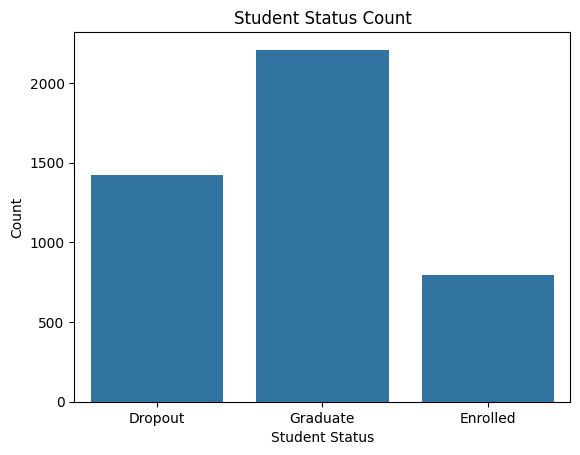

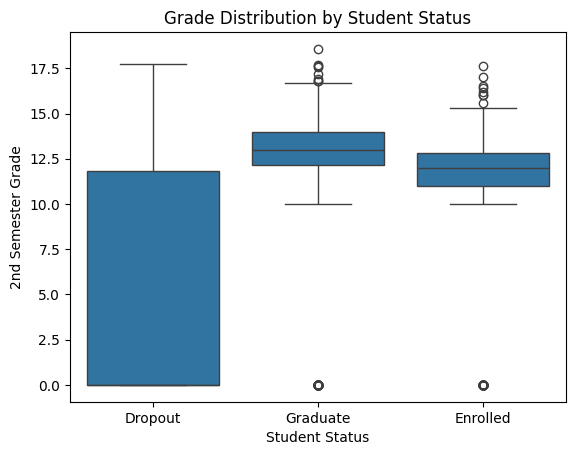

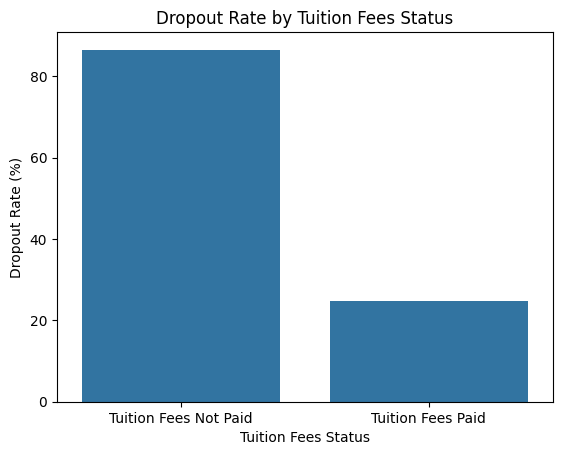

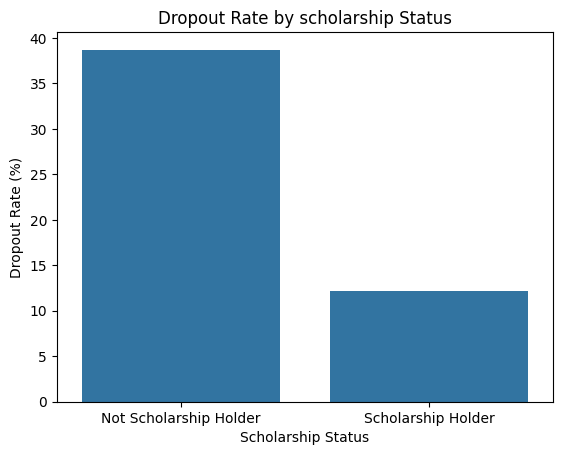

In [9]:
# Exploratory Data Analysis

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check the distribution of the target variable
print("\nClass Rate")
dropout_rate = (df["target"].where(df["target"] == "Dropout").count() / df["target"].count())*100
print("Dropout Rate:", round(dropout_rate, 2), "%")
graduation_rate = (df["target"].where(df["target"] == "Graduate").count() / df["target"].count())*100
print("Graduation Rate:", round(graduation_rate, 2), "%")
enrollment_rate = (df["target"].where(df["target"] == "Enrolled").count() / df["target"].count())*100
print("Enrollment Rate:", round(enrollment_rate, 2), "%")

# Check the counts of each class
print("\nClass Counts:")
dropout_count = df["target"].where(df["target"] == "Dropout").count()
graduation_count = df["target"].where(df["target"] == "Graduate").count()
enrollment_count = df["target"].where(df["target"] == "Enrolled").count()
print("Dropout Count:", dropout_count)
print("Graduation Count:", graduation_count)
print("Enrollment Count:", enrollment_count)


# Visualize the distribution of the target variable
sns.countplot(data=df, x="target")
plt.title("Student Status Count")
plt.xlabel("Student Status")
plt.ylabel("Count")
plt.show()

# Visualize the distribution of grades by student status
sns.boxplot(data=df, x="target", y="Curricular units 2nd sem (grade)")
plt.title("Grade Distribution by Student Status")
plt.xlabel("Student Status")
plt.ylabel("2nd Semester Grade")
plt.show()


#Visualize the dropout rate based on tuition fees status
tuition_fees_not_paid_df = df[df["Tuition fees up to date"] == 0]
dropout_rate_tuition_fees_not_paid = (tuition_fees_not_paid_df["target"].where(tuition_fees_not_paid_df["target"] == "Dropout")).count() / tuition_fees_not_paid_df["target"].count() * 100

tuition_fees_paid_df = df[df["Tuition fees up to date"] == 1]
dropout_rate_tuition_fees_paid = (tuition_fees_paid_df["target"].where(tuition_fees_paid_df["target"] == "Dropout")).count() / tuition_fees_paid_df["target"].count() * 100

sns.barplot(x=["Tuition Fees Not Paid", "Tuition Fees Paid"], y=[dropout_rate_tuition_fees_not_paid, dropout_rate_tuition_fees_paid])
plt.title("Dropout Rate by Tuition Fees Status")
plt.xlabel("Tuition Fees Status")   
plt.ylabel("Dropout Rate (%)")
plt.show()


#Visualize the dropout rate based on scholarship status
scholarship_holder_df = df[df["Scholarship holder"] == 1]
dropout_rate_scholarship = (scholarship_holder_df["target"].where(scholarship_holder_df["target"] == "Dropout")).count() / scholarship_holder_df["target"].count() * 100

scholarship_non_holder_df = df[df["Scholarship holder"] == 0]
dropout_rate_non_scholarship = (scholarship_non_holder_df["target"].where(scholarship_non_holder_df["target"] == "Dropout")).count() / scholarship_non_holder_df["target"].count() * 100

sns.barplot(x=["Not Scholarship Holder", "Scholarship Holder"], y=[dropout_rate_non_scholarship, dropout_rate_scholarship])
plt.title("Dropout Rate by scholarship Status")
plt.xlabel("Scholarship Status")   
plt.ylabel("Dropout Rate (%)")
plt.show()




# Train Test Split

I transformed the target class into numeric values and I then separated the data into a 80-20 train test split. I used Stratification, which ensures the number of values that get assigned to each group is balanced, on the target class to help with the class imbalance.

In [10]:
# Train Test Split

#Seperate features and target variable
x = df.drop(labels="target", axis=1)
y = df["target"]

#Encode the target variable
label_ecoder = LabelEncoder()
y = label_ecoder.fit_transform(y)

#Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=23364203, stratify=y
    
)


# Preprocessing 

I built a preprocessor that OneHotEncodes categorical attributes and leaves numeric attributes unchanged as scaling occurs later in the pipeline. I used OneHotEncoding because none of the categorical attributes have a ordinal relationship.  

In [11]:
# Preprocess

categorical_cols = [
    'Marital Status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'International'
]

numeric_cols = [
    'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

#Find the unique categories for each categorical column in the training set
categorical_categories = [np.sort(x_train[col].unique()) for col in categorical_cols]


#Create a column transformer to preprocess the data
preproccessor = ColumnTransformer(
    transformers = [
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", categories=categorical_categories, sparse_output=False), categorical_cols)
    ]
)


# Feature Selection

I created a barplot showing the mutual information, a score indicating the dependency between 
two variables, between the 25 features with the highest mutual information and the target class. 
We can see that there is a steep drop off after 4 features and another smaller drop off at 8
features before a more gradual decline through the remaining 17 features. 

I then created a feature selector that selects 8 features using mutual information as the score.
I choose to have 8 features selected as this would provide a balance between overfitting and 
capturing signal. 

Note: Due to one hot encoding 8 separate features may not be included in the models as each
dummy value will be counted as a feature selected. In this instance there would only be 
seven features selected as `tuition_fees_up_to_date_0` and `tuition_fees_up_to_date_1` would
both be in the features selected.

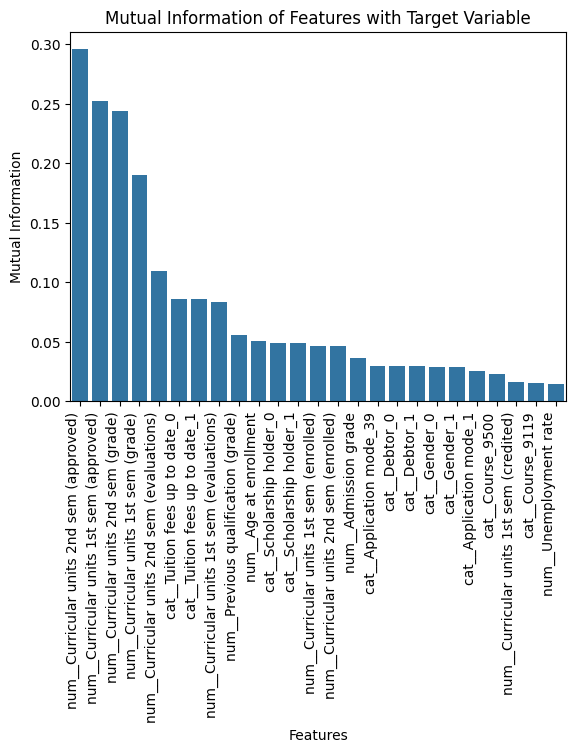

In [12]:
#Encode the training data and get the feature names
x_train_encoded = preproccessor.fit_transform(x_train)
feature_names = preproccessor.get_feature_names_out()

#Find the discrete features for mutual information calculation
discrete_features = [name.startswith("cat") for name in feature_names]

#Find the mutual information of each feature with the target variable
mutual_info = mutual_info_classif(
    x_train_encoded, 
    y_train, 
    discrete_features=discrete_features,
    random_state=23364203)

#Create a dataframe to visualize the mutual information of each feature with the target variable
mi_df = pandas.DataFrame({
    "Feature": feature_names, 
    "Mutual Information": mutual_info
    }).sort_values(by="Mutual Information", ascending=False)

#Plot the mutual information of each feature with the target variable
sns.barplot(x=feature_names, y=mutual_info, order=mi_df[0:25].sort_values(by="Mutual Information", ascending=False).Feature)
plt.xticks(rotation=90, ha="right")
plt.title("Mutual Information of Features with Target Variable")
plt.xlabel("Features")
plt.ylabel("Mutual Information")    
plt.show()


#Create a SelectKBest object to select the top 8 features based on mutual information
mi_score_func = partial(
    mutual_info_classif,
    discrete_features=discrete_features,
    random_state=23364203
)

selector = SelectKBest(score_func=mi_score_func, k=8)


# KNN

I built the pipeline for the KNN model which OneHotEncodes categorical variables, selects the 8 best features, scales the data, and finally applies the model.
I then fitted the training data to the model and had the model make predictions for the test features. 

We can see that the model achieved an accuracy of about 0.69 and had an F1 macro score of about 0.63. If we examine the classification report, with 0 = Dropout, 
1 = Enrolled, and 2 = Graduate we see that the model was best at finding students who graduated with an f1-score of 0.80, was a bit worse at identifying students
who dropped out with an f1-score of 0.70, and struggled to identify students who are currently enrolled with an f1-score of 0.39. It is not surprising that 
the model struggled at identifying student still currently enrolled, likely because they are students who have simply not yet graduated or dropped out and there 
is no information in the dataset that would differentiate them from the other classes, as Enrolled is a timing snapshot rather than a specific outcome. This is 
further supported by the confusion matrix which shows us that the Dropout and Graduate classes are more or just as often confused with the Enrolled class as they
are with each other, and the Enrolled class gets misclassified between the Dropout and Graduate classes evenly, both of which are consistent with the fact that 
enrolled students will eventually either dropout or graduate.

If we look at the precision and recall for each class we can see that there is not a substantial difference between them, showing that the model
is neither over-predicting nor under-predicting each class systematically. 

After hyperparameter tuning we will look at how this model compares to the tuned model.


In [13]:
#KNN 

#Create Pipeline for KNN model
knn_pipeline = Pipeline([
    ("preproccessor", preproccessor),
    ("selector", selector),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=1))
])

#Fit the KNN pipeline to the training data
knn_pipeline.fit(x_train, y_train)

#Predict the target variable for the test data
y_pred = knn_pipeline.predict(x_test)

b_knn_accuracy = accuracy_score(y_test, y_pred)

b_knn_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy: ", b_knn_accuracy)
print("F1 Score: ", b_knn_f1)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy:  0.6937853107344633
F1 Score:  0.6290030857967913
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.71      0.70       284
           1       0.39      0.38      0.39       159
           2       0.81      0.79      0.80       442

    accuracy                           0.69       885
   macro avg       0.63      0.63      0.63       885
weighted avg       0.69      0.69      0.69       885

Confusion Matrix:
 [[202  51  31]
 [ 44  61  54]
 [ 46  45 351]]


# KNN Hyperparameter Tuning

I created a parameter grid with the  number of neighbors, weights, and metric as the parameters.I then used scikit-learn's `GridSearchCV()` to find the best parameter set for the KNN model.


In [29]:
#KNN Hyperparameter Tuning

# Create parameter grid
param_grid_knn = {
    'model__n_neighbors': np.arange(1, 21),
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

# Create a GridSearchCV object to find the best hyperparameters for the KNN model
knn_grid_search = GridSearchCV(
    knn_pipeline, 
    param_grid_knn, 
    cv=5, 
    scoring='f1_macro',
    n_jobs=-1)

# Fit the GridSearchCV object to the training data
knn_grid_search.fit(x_train, y_train)

# Find the best the best model
best_knn = knn_grid_search.best_estimator_

# KNN Learning Curve

I used scikit-learn's `learning_curve()` to find the F1 macro scores for the KNN model at various training sizes, then plotted both the training and validation curves to see how the model's performance and generalization change as sample size grows.

The plot shows a persistent gap between the training and validation scores that does not close even as the training size approaches its maximum, indicating that the model is overfitting rather than being limited by data volume. This means more data alone would be unlikely to meaningfully improve performance. Since the model's complexity for KNN is controlled by the number of neighbors, increasing k further could help close this gap by smoothing predictions over a larger neighborhood. However, this could decrease the model's performance on the Enrolled class as a larger k causes the model to lean more heavily on the locally most common class when making predictions, which would likely reduce recall for Enrolled further, since it is already the minority class. 

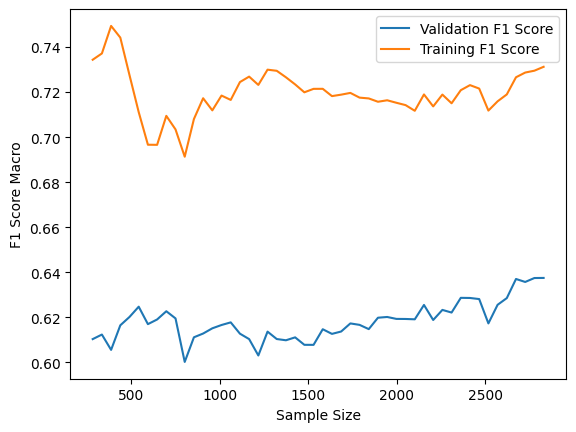

In [30]:
#KNN Learning Curve

#Find the learning curve for the best KNN model
train_sizes, train_scores, val_scores = learning_curve(
    best_knn,
    x_train,
    y_train,
    cv=5,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0),
    n_jobs=-1
)



#Plot the learning curve
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation F1 Score')
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training F1 Score')
plt.xlabel('Sample Size')
plt.ylabel('F1 Score Macro')
plt.legend()
plt.show()

# KNN Final Evaluation

I fitted the best KNN model found in the KNN hyperparameter tuning section with the training data. I then had the model make predictions for the test features. 

We can see that the model achieved an accuracy of about 0.71 and an F1 macro of about 0.63. While the accuracy did improve from the baseline model the f1-score
did not. However, if we look at the classification report closely, we can see that the f1-score did improve for both the Dropout and Graduate classes with an f1-score 
of 0.72 for the Dropout class and 0.83 for the Graduate class, while the f1-score for the Enrolled class decreased with a score of 0.34. This is consistent with the 
previous observation that there is no information in the dataset that can help the model classify enrolled students. The confusion matrix also shows a similar pattern 
to the one in the baseline model with the Dropout and Graduate classes being confused with the Enrolled class as often or more often than they are with each other.

If we look at the precision and recall for each class we see that the precision increased slightly for the Graduate class, decreased slightly for the Dropout class,
and remained the same for the Enrolled class, while the recall increased for both the Dropout and Graduate classes and decreased for the Enrolled class. This is likely 
due to the fact that during hyperparameter tuning, k=5 was selected as the best k value for the model. This means that the model will look at the nearest 5 instances to 
determine the class rather than the baseline's k=1 which will only look at the nearest instance. This will cause smaller classes, such as Enrolled, to be mistakenly classified 
as larger classes. This explains why recall would decline for the Enrolled class. Additionally, if we compare the confusion matrix from the baseline model to this model's
confusion matrix, we can see that the model is placing the increased misclassified Enrolled instances into the Dropout class which also explains the slight decrease in 
the Dropout class's precision. 

We will now look at how a Logistic Regression model performs on this dataset.



In [31]:
#KNN Final Evaluation

#Fit best KNN model to the training data
best_knn.fit(x_train, y_train)

y_pred = best_knn.predict(x_test)

knn_accuracy = accuracy_score(y_test, y_pred)
knn_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", knn_accuracy)
print("F1 Score: ", knn_f1)
print( classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Best Parameters:", knn_grid_search.best_params_)

Accuracy: 0.7129943502824859
F1 Score:  0.6270992222270074
              precision    recall  f1-score   support

           0       0.68      0.75      0.72       284
           1       0.39      0.30      0.34       159
           2       0.82      0.84      0.83       442

    accuracy                           0.71       885
   macro avg       0.63      0.63      0.63       885
weighted avg       0.70      0.71      0.70       885

Confusion Matrix:
 [[213  39  32]
 [ 60  47  52]
 [ 38  33 371]]
Best Parameters: {'model__metric': 'euclidean', 'model__n_neighbors': np.int64(5), 'model__weights': 'uniform'}


# Logistic Regression

I built the pipeline for the Logistic Regression model which OneHotEncodes categorical variables, selects the 8 best features, scales the data, and finally applies the model.
I then fitted the training data to the model and had the model make predictions for the test features. 

The model achieved an accuracy of about 0.75 and a f1 macro score of about 0.66, outperforming the baseline KNN model in both accuracy and f1-score. Looking at the classification
report we can see that both the Dropout and Graduate f1-scores increased from the baseline KNN model with scores of 0.77 and 0.84 respectively, while the Enrolled class's f1-score 
decreased slightly with a score of 0.37. Looking at the confusion matrix we see that, similar to the KNN models, the Graduate and Dropout classes are mistaken as Enrolled students
a similar amount as they are mistaken as each other with 30 Dropout students being misclassified as Enrolled students and 40 being misclassified as Graduate students, and 20 Graduate students being misclassified as Dropout students and 20 being misclassified as Enrolled students. This model however, misclassified 75 Enrolled students as Graduate students and 37 Enrolled students as Dropout students compared to the baseline KNN model's 54 Enrolled students as Graduate students and 44 Enrolled students as Dropout students, showing that this model leans toward misclassifying Enrolled students as Graduate students rather than Dropout students. This may be because the model is identifying signs in the Enrolled class about whether the student will ultimately Graduate or Dropout, though it may reflect Logistic Regression's decision boundary being influenced by overall class frequency. In order to test this I created data frames containing the Dropout and Graduate student misclassifications for Enrolled students and printed the mean of the features with the highest MI score. The results showed that Graduate student misclassifications had about 5.25 approved units with a grade of 12.11 for the 1st semester and 5.23 approved units with a grade of 12.53 for the 2nd semester, while Dropout student misclassifications  had about 2.24 approved units with a grade of 8.70 for the 1st semester and 1.78 approved units with a grade of 8.56 for the 2nd semester  indicating that the model is placing Enrolled in classes based on their ultimate trajectory.

Compared to the baseline KNN model, the precision increased for all classes while the recall increased for the Dropout and Graduate classes and decreased for the Enrolled class.

We will now perform hyperparameter tuning on the model and compare how its results change.

In [18]:
#Logistic Regression

#Create Pipeline for Logistic Regression model
logistic_regression_pipeline = Pipeline([
    ("preproccessor", preproccessor),
    ("selector", selector),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

#Fit the Logistic Regression pipeline to the training data
logistic_regression_pipeline.fit(x_train, y_train)

#Predict the target variable for the test data
y_pred = logistic_regression_pipeline.predict(x_test)

b_lr_accuracy = accuracy_score(y_test, y_pred)
b_lr_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", b_lr_accuracy)
print("F1 Score: ", b_lr_f1)
print( classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Create new df with true and predicted values for misclassification analysis
results_df = x_test.copy()
results_df["True"] = y_test
results_df["Predicted"] = y_pred

# Create new dataframes for misclassifications
graduate_misclassifications = results_df[(results_df["True"] == 1) & (results_df["Predicted"] == 2)]
dropout_misclassifications = results_df[(results_df["True"] == 1) & (results_df["Predicted"] == 0)]

print("\nMissclassified as Graduate student 1st semester units mean:", graduate_misclassifications["Curricular units 1st sem (approved)"].mean())
print("Missclassified as Dropout student 1st semester units mean:", dropout_misclassifications["Curricular units 1st sem (approved)"].mean())

print("\nMissclassified as Graduate student 2nd semester units mean:", graduate_misclassifications["Curricular units 2nd sem (approved)"].mean())
print("Missclassified as Dropout student 2nd semester units mean:", dropout_misclassifications["Curricular units 2nd sem (approved)"].mean())


print("\nMissclassified as Graduate student 1st semester grade mean:", graduate_misclassifications["Curricular units 1st sem (grade)"].mean())
print("Missclassified as Dropout student 1st semester grade mean:", dropout_misclassifications["Curricular units 1st sem (grade)"].mean())

print("\nMissclassified as Graduate student 2nd semester grade mean:", graduate_misclassifications["Curricular units 2nd sem (grade)"].mean())
print("Missclassified as Dropout student 2nd semester grade mean:", dropout_misclassifications["Curricular units 2nd sem (grade)"].mean())



Accuracy: 0.7491525423728813
F1 Score:  0.6589106588992538
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       284
           1       0.48      0.30      0.37       159
           2       0.78      0.91      0.84       442

    accuracy                           0.75       885
   macro avg       0.68      0.65      0.66       885
weighted avg       0.73      0.75      0.73       885

Confusion Matrix:
 [[214  30  40]
 [ 37  47  75]
 [ 20  20 402]]

Missclassified as Graduate student 1st semester units mean: 5.253333333333333
Missclassified as Dropout student 1st semester units mean: 2.2432432432432434

Missclassified as Graduate student 2nd semester units mean: 5.226666666666667
Missclassified as Dropout student 2nd semester units mean: 1.7837837837837838

Missclassified as Graduate student 1st semester grade mean: 12.106302092666665
Missclassified as Dropout student 1st semester grade mean: 8.699420849729728

Missclassified as Gradu

# Logistic Regression Hyperparameter Tuning

I created a parameter grid with the c value as the parameter. then used scikit-learn's `GridSearchCV()` to find the best c value for the Logistic Regression model.

In [19]:
#Logistic Regression Hyperparameter Tuning

#Create parameter grid
param_grid_lr = {
    "model__C": [.001, .01, .1, 1, 10, 100]
}

#Create a GridSearchCV object to find the best hyperparameters for the Logistic Regression model
grid_search = GridSearchCV(
    logistic_regression_pipeline,
    param_grid_lr,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

#Fit the GridSearchCV object to the training data
grid_search.fit(x_train, y_train)

#Find the best model
best_lr = grid_search.best_estimator_

# Logistic Regression Learning Curve


I used scikit-learn's `learning_curve()` to find the F1 macro scores for the Logistic Regression model at various sample sizes. I then created a plot to view how the performance of the model changes at various sizes.

Unlike the KNN model, the plot for this model shows that the validation score and training score remain close together throughout the plot, indicating that the model is underfitting rather than overfitting. However, we see that the validation and training scores plateau around the f1-score of 0.62. Because the scores are already close together, this indicates that the problem is not due to a lack of training data but either the number of features available or the linear decision boundary Logistic Regression is restricted to, as Logistic Regression can only draw linear boundaries across the 8 selected features, a more complex relationship between them and the outcome would remain out of reach regardless of sample size.

This contrasts with the KNN model's learning curve which showed clear signs of overfitting. Both models however, achieved similar accuracy and f1-scores indicating that they are both limited by different ceilings.

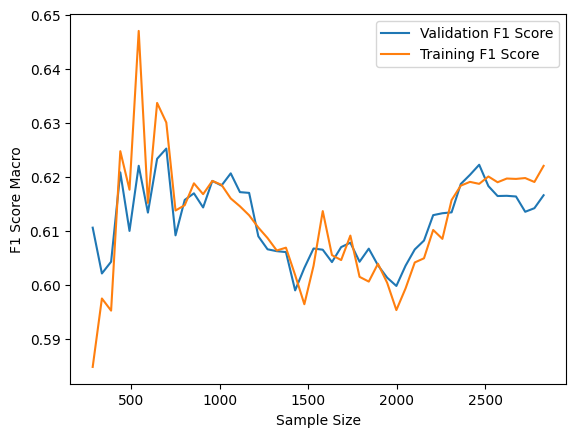

In [20]:
#Logistic Regression Learning Curve

#Find the learning curve for the best Logistic Regression model
train_sizes, train_scores, val_scores = learning_curve(
    best_lr,
    x_train,
    y_train,
    cv=5,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0),
    n_jobs=-1
)

#Plot the learning curve
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation F1 Score')
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training F1 Score')
plt.xlabel('Sample Size')
plt.ylabel('F1 Score Macro')
plt.legend()
plt.show()

# Logistic Regression Final Evaluation

I fitted the best Logistic Regression model found in the Logistic Regression hyperparameter tuning section with the training data. I then had the model make predictions for the test features. 

We can see that the model achieved an accuracy of about 0.75 and an f1 macro score of 0.66, which is almost identical to the baseline model. If we look at the confusion matrix we see that the only change from the baseline model was that one Enrolled student was correctly classified where the baseline model misclassified it as a Graduate student. Given that 10 was selected as the C value during hyperparameter tuning compared with the default C of 1.0 for scikit-learn's `LogisticRegression()` function, the model's performance on this dataset seems to be largely unaffected by the regularization strength. 

We will now examine how a Random Forest model performs on the dataset


In [21]:
#Logistic Regression Final Evaluation


#Fit best Logistic Regression model to the training data
best_lr.fit(x_train, y_train)

y_pred = best_lr.predict(x_test)

lr_accuracy = accuracy_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", lr_accuracy)
print("F1 Score: ", lr_f1)
print( classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print(grid_search.best_params_)



Accuracy: 0.7502824858757062
F1 Score:  0.6613201538134318
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       284
           1       0.49      0.30      0.37       159
           2       0.78      0.91      0.84       442

    accuracy                           0.75       885
   macro avg       0.69      0.65      0.66       885
weighted avg       0.73      0.75      0.73       885

Confusion Matrix:
 [[214  30  40]
 [ 37  48  74]
 [ 20  20 402]]
{'model__C': 10}


# Random Forest

I built the pipeline for the Random Forest model which OneHotEncodes categorical variables, selects the 8 best features, and finally applies the model. I then fitted the training data to the model and had the model make predictions for the test features. 

The Random Forest model achieved an accuracy of about 0.73 and a f1 macro score of about 0.65, outperforming both KNN models and slightly underperforming the baseline and tuned Logistic Regression model. Looking at the classification report, like the other models, the model struggled to classify Enrolled students with an f1-score of 0.35 for the Enrolled class, while performing similarly to the Logistic Regression at classifying the other classes with an f1-score of 0.76 for the Dropout class and an f1-score of .83 for the Graduate class. 

Looking at the Confusion Matrix we see that it looks similar to the confusion matrix for the final Logistic Regression model, misclassifying Dropout and Graduate students as the other classes at a similar rate. The uneven distribution of the Enrolled class toward the Graduate class is also present with the model misclassifying 45 Enrolled students as Dropout students and 66 Enrolled students as Graduate students a roughly 41/59 split, close to the Logistic Regressions 33/67 split, supporting the idea that the misclassifications of Enrolled students reflect their eventual trajectory. Interestingly, the model correctly classified the same number of Enrolled students that the final logistic regression model did. 

We will now compare the results after hyperparameter tuning.

In [22]:
#Random Forest

#Create Pipeline for Random Forest model
rf_pipeline = Pipeline([
    ("preproccessor", preproccessor),
    ("selector", selector),
    ("model", RandomForestClassifier(random_state=23364203))
])

#Fit the Random Forest pipeline to the training data
rf_pipeline.fit(x_train, y_train)

#Predict the target variable for the test data
y_pred = rf_pipeline.predict(x_test)

b_rf_accuracy = accuracy_score(y_test, y_pred)
b_rf_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", b_rf_accuracy)
print("F1 Score: ", b_rf_f1)
print( classification_report(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.7310734463276836
F1 Score:  0.6448176488046767
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       284
           1       0.40      0.30      0.35       159
           2       0.80      0.87      0.83       442

    accuracy                           0.73       885
   macro avg       0.65      0.64      0.64       885
weighted avg       0.71      0.73      0.72       885

Confusion Matrix:
 [[216  36  32]
 [ 45  48  66]
 [ 24  35 383]]


# Random Forest Hyperparameter Tuning

I created a parameter grid with the number of estimators, max depth, min sample splits, and min sample leaves as the parameters. I then used scikit-learn's `GridSearchCV()` to find the best parameter set for the Random Forest model.

In [23]:
#Random Forest Hyperparameter Tuning

#Create parameter grid
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
}

#Create a GridSearchCV object to find the best hyperparameters for the Random Forest model
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

#Fit the GridSearchCV object to the training data
grid_search.fit(x_train, y_train)

#Find the best model
best_rf = grid_search.best_estimator_

# Random Forest Learning Curve


I used scikit-learn's `learning_curve()` to find the F1 macro scores for the Random Forest model at various sample sizes. I then created a plot to view how the performance of the model changes at various sizes.

The plot shows a very large gap between the training scores, which start around 0.86, and validation scores, which start around 0.60, showing us that the model is overfitting. Unlike the KNN learning curve however, as the data size increases the gap shrinks, with the final training score around 0.79 and the final validation score around 0.64, suggesting that more data may improve the model's performance. 

Comparing all three models' learning curves we see that the KNN model showed a clear, stable gap between the training and validation scores, the Logistic Regression model showed signs of underfitting, converging at a low, flat rate, and the Random Forest model showed a gap that is actively decreasing as the data size increases. The fact that all three models had a similar final F1 Macro score however, suggests that these ceilings may have more to do with a limitation of the dataset, such as the ambiguity of the Enrolled class, rather than any one model's specific limitations.

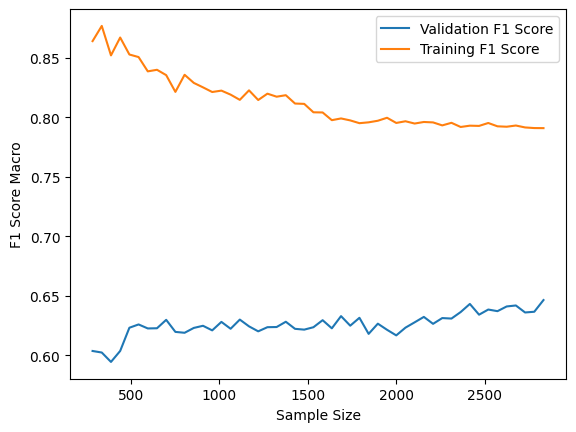

In [24]:
#Random Forest Learning Curve

#Find the learning curve for the best Random Forest model
train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    x_train,
    y_train,
    cv=5,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0),
    n_jobs=-1
)

#Plot the learning curve
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation F1 Score')
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training F1 Score')
plt.xlabel('Sample Size')
plt.ylabel('F1 Score Macro')
plt.legend()
plt.show()

# Random Forest Final Evaluation

I fitted the best Random Forest model found in the Random Forest hyperparameter tuning section with the training data. I then had the model make predictions for the test features.

The model achieved an accuracy of about 0.75 and an f1 macro score of about 0.66, outperforming the baseline model and the KNN models and performing nearly identically to the Logistic Regression models. In fact, the model correctly classified the exact same number of students as the baseline Logistic Regression model. Comparing the confusion matrix of both models however, shows that the same set of students were not correctly classified. If we examine the classification report we see that the model achieved a higher f1-score for all classes with scores of 0.78 for the Dropout class, 0.36 for the Enrolled class, and 0.84 for the Graduate class. If we compare the precision and recall to the baseline model we see that both precision and recall increase for all classes except Graduate precision where it declined by 0.01 and Enrolled precision where it remained the same.

Looking at the confusion matrix we see that the model had nearly the same split between the classifications of the Enrolled class, only misclassifing one more Enrolled student as a Graduate student.

We will now compare the results of all the models.

In [25]:
#Random Forest Final Evaluation

#Fit the Random Forest pipeline to the training data
best_rf.fit(x_train, y_train)

#Predict the target variable for the test data
y_pred = best_rf.predict(x_test)

rf_accuracy = accuracy_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", rf_accuracy)
print("F1 Score: ", rf_f1)
print( classification_report(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print(grid_search.best_params_)

Accuracy: 0.7491525423728813
F1 Score:  0.6589799472754317
              precision    recall  f1-score   support

           0       0.78      0.77      0.78       284
           1       0.45      0.30      0.36       159
           2       0.79      0.90      0.84       442

    accuracy                           0.75       885
   macro avg       0.68      0.66      0.66       885
weighted avg       0.73      0.75      0.73       885

Confusion Matrix:
 [[220  27  37]
 [ 45  47  67]
 [ 16  30 396]]
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}


# Model Comparison

If we compare all the models we can see that the KNN model performed distinctly worse than the Logistic Regression and Random Forest models. The Random Forest and Logistic Regression models however, had very similar scores for both metrics with the Logistic Regression model having an accuracy of about 0.75 and a f1-score of about 0.66 and the Random Forest model having an accuracy of about 0.75 and a f1-score of about 0.66. Because it is more important to identify all students who are at risk of dropping out than it is to ensure the accuracy of the students predicted to dropout however, the recall of the Dropout class is particularly important. That is why my final recommendation would be the Random Forest model as it had a higher recall for the Dropout class with a score of 0.77 compared to the Logistic Regressions 0.75. The Logistic Regression model did however have a slightly higher precision for the Dropout class with a score of 0.79 compared to the Random Forest's precision for the Dropout class of 0.78 so this recommendation prioritizes catching more at risk students than ensuring there are fewer false positives. 

If we compare the baseline models to the tuned models we see that the tuned KNN model had the greatest increase in accuracy with a difference of .019209, the Random Forest had the next highest increase of 
.01808, and the Logistic Regression had the smallest increase of .00129. If we look at the f1-scores we see that the Random Forest model had the highest increase with a difference of .014162, the Logistic Regression model had the next highest increase with a difference of .002409, and the KNN model decreased by .001904. 

If we compare the performance of the models on each class we see that the models performed the best on the Graduate class with an average f1-score of 0.83, the next best on the Dropout class with an average f1-score of 0.75, and the worst on the Enrolled class with an average f1-score of 0.36. As discussed throughout the notebook, the models struggled to classify the Enrolled students likely due to the fact that it is a timing snapshot rather than a completed trajectory. We also saw the Logistic Regression and Random Forest model misclassified the Enrolled students as either Dropouts or Graduates at a similar rate to the actual class balance potentially indicating the model is misclassifying them based on their ultimate trajectory. This is also supported by the fact that the baseline Logistic Regression's Enrolled students who were misclassified as Graduate students had higher approved units and had higher grades for both the 1st and 2nd semesters than its Enrolled students who were misclassified as Dropouts. 

In [59]:
results_df = pandas.DataFrame()

results_df["Model"] = ["KNN", "Logistic Regression", "Random Forest"]
results_df["Baseline Accuracy"] = [b_knn_accuracy, b_lr_accuracy, b_rf_accuracy]
results_df["Accuracy"] = [knn_accuracy, lr_accuracy, rf_accuracy]
results_df["Baseline F1 Score"] = [b_knn_f1, b_lr_f1, b_rf_f1]
results_df["F1 Score"] = [knn_f1, lr_f1, rf_f1]

display(results_df)

,Model,Baseline Accuracy,Accuracy,Baseline F1 Score,F1 Score
0,KNN,0.693785,0.712994,0.629003,0.627099
1,Logistic Regression,0.749153,0.750282,0.658911,0.661320
2,Random Forest,0.731073,0.749153,0.644818,0.658980
